# A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles 
This is the code for the paper entitled "**A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles**" accepted in IEEE International Conference on Communications (IEEE ICC).  
Authors: Li Yang (lyang339@uwo.ca) and Abdallah Shami (Abdallah.Shami@uwo.ca)  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

**Notebook 1: Data pre-processing**  
Procedures:  
&nbsp; 1): Read the dataset  
&nbsp; 2): Transform the tabular data into images  
&nbsp; 3): Display the transformed images  
&nbsp; 4): Split the training and test set  

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import math
import random
import matplotlib.pyplot as plt
import shutil
from sklearn.preprocessing import QuantileTransformer
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

## Read the Car-Hacking/CAN-Intrusion dataset
The complete Car-Hacking dataset is publicly available at: https://ocslab.hksecurity.net/Datasets/CAN-intrusion-dataset  
In this repository, due to the file size limit of GitHub, we use the 5% subset.

In [2]:
import glob
import pandas as pd

path = 'D:\PFC\PFC_Impl\MachineLearningCSV\MachineLearningCVE' 
all_files = glob.glob(path + "/*.csv")

li = []
for filename in all_files:
    df_temp = pd.read_csv(filename, index_col=None, header=0)
    li.append(df_temp)

df = pd.concat(li, axis=0, ignore_index=True)

features_20 = [
    ' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
    'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
    ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
    'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
    ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean',
    ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', ' Label'
]

df = df[features_20]

df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [3]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3,3,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,6,6.0,0.0,1.100917e+05,18348.623850,109.0,0.000000,109,109,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,6,6.0,0.0,2.307692e+05,38461.538460,52.0,0.000000,52,52,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,6,6.0,0.0,3.529412e+05,58823.529410,34.0,0.000000,34,34,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3,3,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,76,76.0,0.0,8.194940e+03,186.248642,6443.0,13617.579480,30780,3,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,181,181.0,0.0,1.376543e+06,12345.679010,108.0,183.597386,320,2,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,6,6.0,0.0,4.512195e+05,36585.365850,41.0,52.325902,78,4,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,128,128.0,0.0,4.272221e+02,7.628965,149805.0,375521.040500,1000947,1,BENIGN


In [4]:
# Primero, nos aseguramos de que no haya valores nulos en Label
df['Label'] = df['Label'].fillna('BENIGN')

# Creamos una columna nueva vacía
df['Label_Group'] = 'Normal' 

# Agrupamos usando búsquedas parciales para evitar el error del caracter ''
df.loc[df['Label'].str.contains('DoS|DDoS|Heartbleed', case=False, na=False), 'Label_Group'] = 'DoS'
df.loc[df['Label'].str.contains('PortScan', case=False, na=False), 'Label_Group'] = 'Port-Scan'
df.loc[df['Label'].str.contains('Patator', case=False, na=False), 'Label_Group'] = 'Brute-Force'
df.loc[df['Label'].str.contains('Web Attack', case=False, na=False), 'Label_Group'] = 'Web-Attack'
df.loc[df['Label'].str.contains('Bot', case=False, na=False), 'Label_Group'] = 'Botnet'

# Reemplazamos la columna original y borramos la temporal
df['Label'] = df['Label_Group']
df.drop(['Label_Group'], axis=1, inplace=True)

# Verificamos - Ahora sí deberían aparecer los Web-Attack
print(df['Label'].value_counts())

Label
Normal         2271356
DoS             379748
Port-Scan       158804
Brute-Force      13832
Web-Attack        2180
Botnet            1956
Name: count, dtype: int64


In [5]:
# The labels of the dataset. "R" indicates normal patterns, and there are four types of attack (DoS, fuzzy. gear spoofing, and RPM spoofing zttacks)
df.Label.value_counts()

Label
Normal         2271356
DoS             379748
Port-Scan       158804
Brute-Force      13832
Web-Attack        2180
Botnet            1956
Name: count, dtype: int64

## Data Transformation
Convert tabular data to images
Procedures:
1. Use quantile transform to transform the original data samples into the scale of [0,255], representing pixel values
2. Generate images for each category (Normal, DoS, Fuzzy, Gear, RPM), each image consists of 27 data samples with 9 features. Thus, the size of each image is 9*9*3, length 9, width 9, and 3 color channels (RGB).

In [6]:
# Transform all features into the scale of [0,1]
numeric_features = df.dtypes[df.dtypes != 'object'].index
scaler = QuantileTransformer() 
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [7]:
# Multiply the feature values by 255 to transform them into the scale of [0,255]
df[numeric_features] = df[numeric_features].apply(
    lambda x: (x*255))

In [8]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min
count,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06
mean,1.265698e+02,1.286206e+02,1.199857e+02,1.248231e+02,1.251519e+02,1.205254e+02,1.251163e+02,1.000349e+02,1.252739e+02,7.327025e+01,1.205341e+02,9.502663e+01,1.207299e+02,6.239725e+01,1.271410e+02,1.264984e+02,1.285161e+02,1.121623e+02,1.286203e+02,1.276502e+02
std,7.126690e+01,7.298374e+01,8.209075e+01,7.684694e+01,7.857616e+01,8.409858e+01,7.856034e+01,9.764629e+01,7.873957e+01,1.017434e+02,8.402957e+01,9.972713e+01,8.418297e+01,9.958464e+01,7.265000e+01,7.281697e+01,7.278420e+01,9.088740e+01,7.290341e+01,7.312177e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.620120e+01,6.560060e+01,1.119294e+02,7.772523e+01,7.045045e+01,6.560060e+01,6.802553e+01,0.000000e+00,6.955706e+01,0.000000e+00,6.572823e+01,0.000000e+00,6.598348e+01,0.000000e+00,6.513148e+01,6.444768e+01,6.636637e+01,0.000000e+00,6.585586e+01,8.512763e+01
50%,1.162688e+02,1.298756e+02,1.119294e+02,1.475375e+02,1.300526e+02,1.291592e+02,1.282658e+02,1.239264e+02,1.285210e+02,0.000000e+00,1.290315e+02,0.000000e+00,1.287763e+02,0.000000e+00,1.276212e+02,1.260417e+02,1.289737e+02,1.291125e+02,1.294668e+02,1.249474e+02
75%,1.720420e+02,1.911071e+02,1.938664e+02,1.900375e+02,1.922072e+02,1.922321e+02,1.924625e+02,1.914414e+02,1.931006e+02,1.923348e+02,1.926539e+02,1.923348e+02,1.930136e+02,1.923674e+02,1.893994e+02,1.891441e+02,1.904104e+02,1.910666e+02,1.908836e+02,1.914414e+02
max,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02,2.550000e+02


All features are in the same scale of [0,255]

### Generate images for each class

In [9]:
df0 = df[df['Label'] == 'Normal'].drop(['Label'], axis=1)
df1 = df[df['Label'] == 'DoS'].drop(['Label'], axis=1)
df2 = df[df['Label'] == 'Port-Scan'].drop(['Label'], axis=1)
df3 = df[df['Label'] == 'Brute-Force'].drop(['Label'], axis=1)
df4 = df[df['Label'] == 'Web-Attack'].drop(['Label'], axis=1)
df5 = df[df['Label'] == 'Botnet'].drop(['Label'], axis=1)

In [15]:
# Generate 9*9 color images for class 0 (BENIGN)
count=0
ims = []

image_path = "train/0/"
os.makedirs(image_path)

for i in range(0, len(df0)):  
    count=count+1
    if count<=60: 
        im=df0.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

In [16]:
# Generate 9*9 color images for class 1 (DoS)
count=0
ims = []

image_path = "train/1/"
os.makedirs(image_path)

for i in range(0, len(df1)):  
    count=count+1
    if count<=60: 
        im=df1.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

In [17]:
# Generate 9*9 color images for class 2 (Port-Scan)
count=0
ims = []

image_path = "train/2/"
os.makedirs(image_path)

for i in range(0, len(df2)):  
    count=count+1
    if count<=60: 
        im=df2.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

In [18]:
# Generate 9*9 color images for class 3 (Brute-Force)
count=0
ims = []

image_path = "train/3/"
os.makedirs(image_path)


for i in range(0, len(df3)):  
    count=count+1
    if count<=60: 
        im=df3.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

In [19]:
# Generate 9*9 color images for class 4 (Web-Attack)
count=0
ims = []

image_path = "train/4/"
os.makedirs(image_path)


for i in range(0, len(df4)):  
    count=count+1
    if count<=60: 
        im=df4.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

In [20]:
# Generate 9*9 color images for class 5 (Botnet)
count=0
ims = []

image_path = "train/5/"
os.makedirs(image_path)


for i in range(0, len(df5)):  
    count=count+1
    if count<=60: 
        im=df4.iloc[i].values
        ims=np.append(ims,im)
    else:
        ims=np.array(ims).reshape(20, 20, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path+str(i)+'.png')
        count=0
        ims = []

## Split the training and test set 

In [21]:
# Create folders to store images
Train_Dir='./train/'
Val_Dir='./test/'
allimgs=[]
for subdir in os.listdir(Train_Dir):
    for filename in os.listdir(os.path.join(Train_Dir,subdir)):
        filepath=os.path.join(Train_Dir,subdir,filename)
        allimgs.append(filepath)
print(len(allimgs)) # Print the total number of images

46356


In [22]:
#split a test set from the dataset, train/test size = 80%/20%
Numbers=len(allimgs)//5 	#size of test set (20%)

def mymovefile(srcfile,dstfile):
    if not os.path.isfile(srcfile):
        print ("%s not exist!"%(srcfile))
    else:
        fpath,fname=os.path.split(dstfile)    
        if not os.path.exists(fpath):
            os.makedirs(fpath)               
        shutil.move(srcfile,dstfile)          
        #print ("move %s -> %s"%(srcfile,dstfile))

In [23]:
# The size of test set
Numbers

9271

In [24]:
# Create the test set
val_imgs=random.sample(allimgs,Numbers)
for img in val_imgs:
    dest_path=img.replace(Train_Dir,Val_Dir)
    mymovefile(img,dest_path)
print('Finish creating test set')

Finish creating test set


In [25]:
#resize the images 224*224 for better CNN training
def get_224(folder,dstdir):
    imgfilepaths=[]
    for root,dirs,imgs in os.walk(folder):
        for thisimg in imgs:
            thisimg_path=os.path.join(root,thisimg)
            imgfilepaths.append(thisimg_path)
    for thisimg_path in imgfilepaths:
        dir_name,filename=os.path.split(thisimg_path)
        dir_name=dir_name.replace(folder,dstdir)
        new_file_path=os.path.join(dir_name,filename)
        if not os.path.exists(dir_name):
            os.makedirs(dir_name)
        img=cv2.imread(thisimg_path)
        img=cv2.resize(img,(224,224))
        cv2.imwrite(new_file_path,img)
    print('Finish resizing'.format(folder=folder))

In [26]:
DATA_DIR_224='./train_224/'
get_224(folder='./train/',dstdir=DATA_DIR_224)

Finish resizing


In [27]:
DATA_DIR2_224='./test_224/'
get_224(folder='./test/',dstdir=DATA_DIR2_224)

Finish resizing


### Display samples for each category

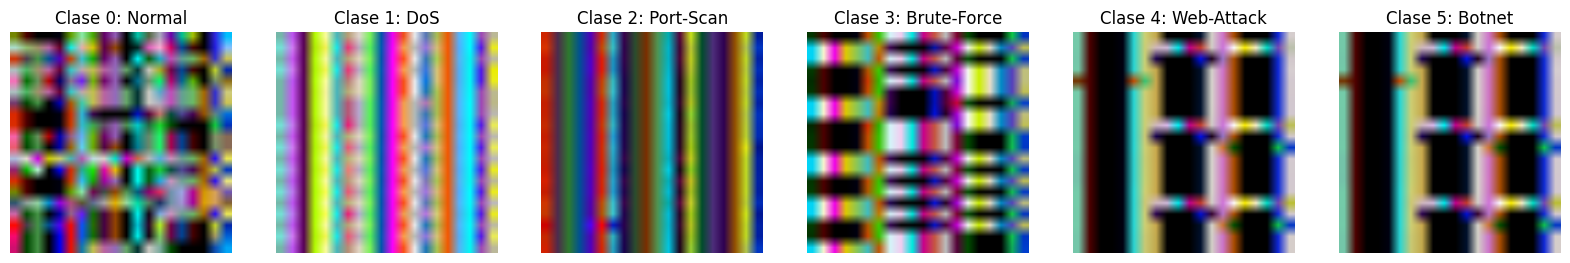

In [42]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Usamos rutas relativas basadas en tu estructura 'tree'
base_path = './train_224/'

# En CICIDS2017 tenemos 6 categorías (0 a 5) según el paper 
categories = ['Normal', 'DoS', 'Port-Scan', 'Brute-Force', 'Web-Attack', 'Botnet']

plt.figure(figsize=(20, 10))

for i in range(6):
    folder_path = os.path.join(base_path, str(i))
    
    # Buscamos el nombre del primer archivo .png en la carpeta
    try:
        files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        if files:
            img_path = os.path.join(folder_path, files[0])
            img = Image.open(img_path)
            
            plt.subplot(1, 6, i + 1)
            plt.imshow(img)
            plt.title(f"Clase {i}: {categories[i]}")
            plt.axis('off')
        else:
            print(f"La carpeta {i} está vacía.")
    except Exception as e:
        print(f"No se pudo abrir la carpeta {i}: {e}")

plt.show()